<a href="https://colab.research.google.com/github/vincent-chen09/MG-Gravitational-waves/blob/main/GW170817_Parameter_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install gwpy
%pip install lalsuite
%pip install bilby

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bilby
from bilby.core.prior import Uniform
from gwpy.timeseries import TimeSeries
from gwpy.signal import filter_design
from gwosc import datasets
logger = bilby.core.utils.logger
outdir = "/content/drive/My Drive/Results_GW170817/"


label = "GW170817"

H1 = bilby.gw.detector.get_empty_interferometer("H1")
L1 = bilby.gw.detector.get_empty_interferometer("L1")

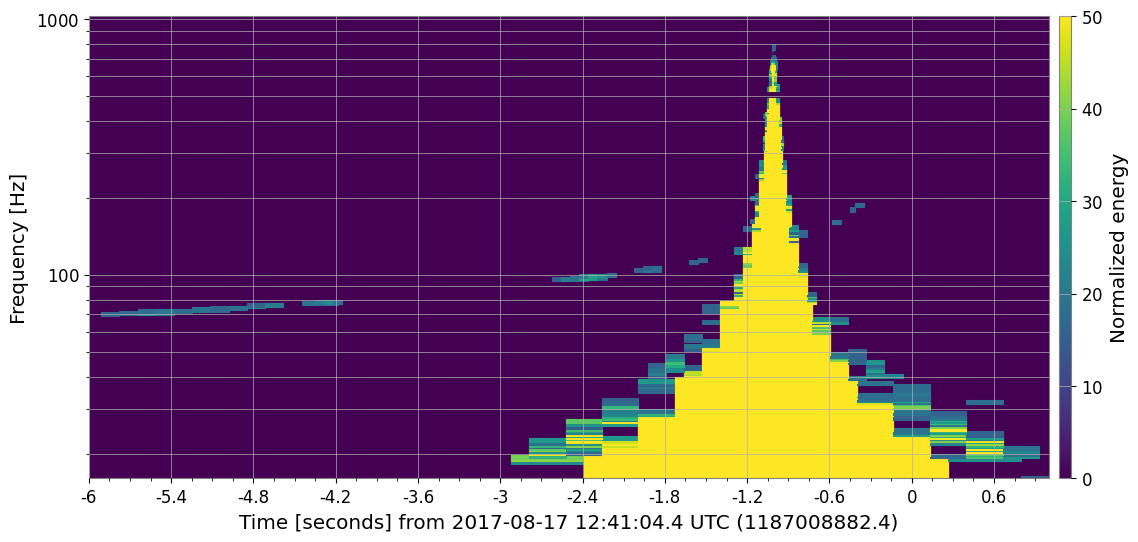

In [ ]:
gps = datasets.event_gps('GW170817')
data = TimeSeries.fetch_open_data('L1', gps-34, gps+34)
from gwpy.segments import Segment
qgram = data.q_gram(
    qrange=(4, 150),
    search=Segment(gps-0.25, gps+0.25),
    mismatch=0.35,
)
plot = qgram.tile(
    'time',
    'frequency',
    'duration',
    'bandwidth',
    color='energy',
)
ax = plot.gca()
ax.set_xscale('seconds')
ax.set_xlim(gps-6, gps+1)
ax.set_epoch(gps)
ax.set_yscale('log')
ax.set_ylim(16, 1024)
ax.set_ylabel('Frequency [Hz]')
ax.grid(True, axis='y', which='both')
from matplotlib import colormaps
cmap = colormaps['viridis']
ax.colorbar(cmap=cmap.name, label='Normalized energy', clim=[0, 50])
ax.set_facecolor(cmap(0))  # colour background to the bottom of the map
plot.show()

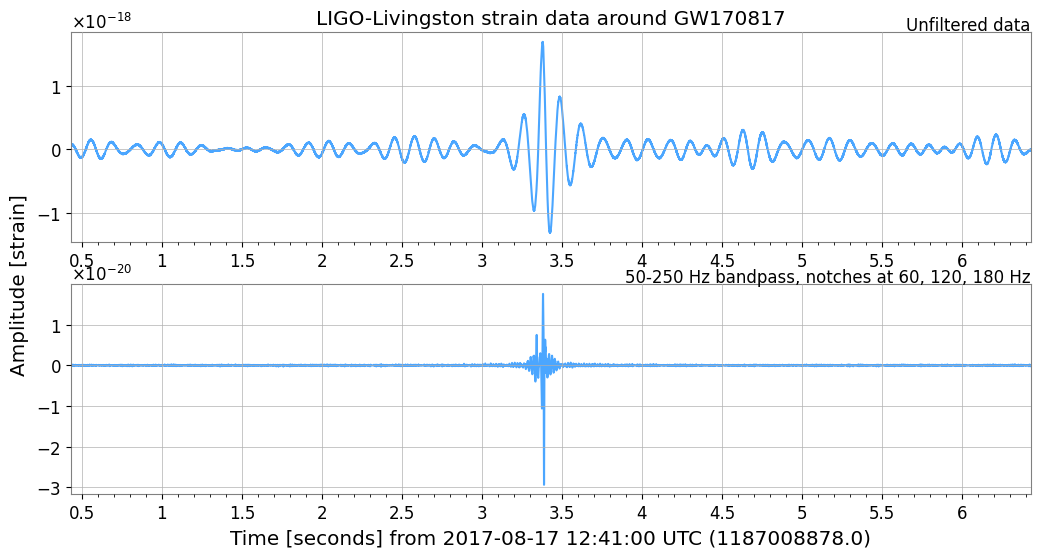

In [ ]:
event_start_time = 1187008881.43      # event GPS time at which GW was discovered
post_event = 4                  # time after event
pre_event = 4                    # time before event
duration = pre_event + post_event  # total time range containing event
analysis_begin = event_start_time - pre_event
L1_data = TimeSeries.fetch_open_data("L1", analysis_begin,
                                     analysis_begin + duration,
                                     sample_rate=4096, cache=True)
lf = 50
hf = 250
bp = filter_design.bandpass(lf, hf, L1_data.sample_rate)
notches = [filter_design.notch(line, L1_data.sample_rate) for
           line in (60, 120, 180, 240, 300, )]
zpk = filter_design.concatenate_zpks(bp, *notches)
lfilt = L1_data.filter(zpk, filtfilt=True)
ldata = L1_data.crop(*L1_data.span.contract(1))
lfilt = lfilt.crop(*lfilt.span.contract(1))
from gwpy.plot import Plot
plot = Plot(ldata, lfilt, figsize=[12, 6], separate=True, sharex=True,
            color='gwpy:ligo-livingston')
ax1, ax2 = plot.axes
ax1.set_title('LIGO-Livingston strain data around GW170817')
ax1.text(1.0, 1.01, 'Unfiltered data', transform=ax1.transAxes, ha='right')
ax1.set_ylabel('Amplitude [strain]', y=-0.2)
ax2.set_ylabel('')
ax2.text(1.0, 1.01, r'50-250 Hz bandpass, notches at 60, 120, 180 Hz',
         transform=ax2.transAxes, ha='right')
plot.show()




In [ ]:
H1_data = TimeSeries.fetch_open_data("H1", analysis_begin,
                                     analysis_begin + duration,
                                     sample_rate=4096, cache=True)
H1.set_strain_data_from_gwpy_timeseries(H1_data)
L1.set_strain_data_from_gwpy_timeseries(L1_data)

In [ ]:
# duration typically multiplied by 32 for psd
psd_duration = duration * 32
psd_begin = analysis_begin - psd_duration

# fetch data for psd
H1psd = TimeSeries.fetch_open_data(
    "H1", psd_begin, psd_begin + psd_duration,
    sample_rate=4096, cache=True)
L1psd = TimeSeries.fetch_open_data(
    "L1", psd_begin, psd_begin + psd_duration,
    sample_rate=4096, cache=True)

# set interferometers with psd data
psd_alpha = 2 * H1.strain_data.roll_off / duration
H1psd_data = H1psd.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
L1psd_data = L1psd.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")
H1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1psd_data.frequencies.value, psd_array=H1psd_data.value)
L1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=L1psd_data.frequencies.value, psd_array=L1psd_data.value)

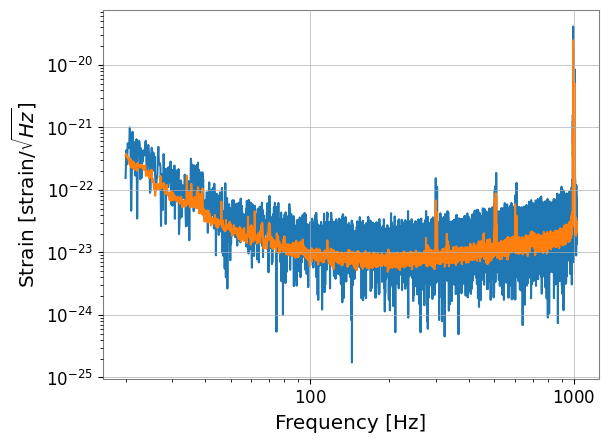

In [ ]:
H1.maximum_frequency = 1024
L1.maximum_frequency = 1024

plt.figure()
idxs = H1.strain_data.frequency_mask
a,b = list(H1.strain_data.frequency_array[idxs]),list(np.abs(H1.strain_data.frequency_domain_strain[idxs]))
c,d = list(H1.power_spectral_density.frequency_array[idxs]),list(H1.power_spectral_density.asd_array[idxs])
plt.plot(a,b)
plt.plot(c,d)
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Frequency [Hz]")
plt.ylabel("Strain [strain/$\sqrt{Hz}$]")
plt.savefig("strainvfreq")


In [ ]:
prior = bilby.core.prior.PriorDict()
# uniform priors for variable parameters
#prior['chirp_mass'] = Uniform(name='chirp_mass', minimum=10.0,maximum=100.0)
prior['mass_ratio'] = Uniform(name='mass_ratio', minimum=0.5, maximum=1)
#prior['phase'] = Uniform(name="phase", minimum=0, maximum=2*np.pi)
#prior['geocent_time'] = Uniform(name="geocent_time", minimum=event_start_time-2,
                                #maximum=event_start_time+2)
#prior['dec'] =  Uniform(name='dec', minimum=-np.pi,maximum=np.pi) #declination
#prior['ra'] =  Uniform(name='ra', minimum=0,maximum=2*np.pi)  #right ascension
prior['a_1'] = Uniform(name='a_1', minimum=0,maximum=0.5)
prior['a_2'] = Uniform(name='a_2', minimum=0,maximum=0.5)

#prior['theta_jn'] =  Uniform(name='theta_jn', minimum=0,maximum=2*np.pi) #angles between line of sight and plane
#prior['psi'] =  Uniform(name='psi', minimum=0,maximum=2*np.pi) #polarization angle of wave
#prior['luminosity_distance'] = Uniform(name="luminosity_distance", minimum =200, maximum = 600)
# fixed values for all other parameters
#prior['a_1'] =  0.0
#prior['a_2'] =  0.0
prior['tilt_1'] =  0.0
prior['tilt_2'] =  0.0
prior['phi_12'] =  0.0
prior['phi_jl'] =  0.0
prior['phase'] = 1.01
prior['dec'] =  -0.408 #declination
prior['ra'] =  3.446  #right ascension
prior['theta_jn'] =  0.35 #angles between line of sight and plane
prior['psi'] =  0 #polarization angle of wave
#prior['mass_ratio'] = 0.87
#prior['phase'] = 0.8
prior['luminosity_distance'] = 40.7
prior['chirp_mass'] = 1.188
prior['geocent_time'] = 1187008882.4
interferometers = [H1, L1]

waveform_arguments = dict(waveform_approximant='IMRPhenomPv2', reference_frequency=50., minimum_frequency=20.)

# set sampling frequency of data
sampling_frequency = 2048.

# generate waveforms
waveform_generator = bilby.gw.WaveformGenerator(duration=duration,
                                                sampling_frequency=sampling_frequency,
                                                frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
                                                parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
                                                waveform_arguments=waveform_arguments)

likelihood = bilby.gw.GravitationalWaveTransient(interferometers=interferometers, waveform_generator=waveform_generator)

21:48 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


21:48 bilby INFO    : Running for label 'GW170817', output will be saved to '/content/drive/My Drive/Results_GW170817/'
21:48 bilby INFO    : Using lal version 7.7.0
21:48 bilby INFO    : Using lal git version Branch: None;Tag: lalsuite-v7.26.1;Id: c90e1175f5e238741185744a4e516e58d42a9aec;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
21:48 bilby INFO    : Using lalsimulation version 6.2.0
21:48 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsuite-v7.26.1;Id: c90e1175f5e238741185744a4e516e58d42a9aec;;Builder: Unknown User <>;Repository status: CLEAN: All modifications committed
21:48 bilby INFO    : Analysis priors:
21:48 bilby INFO    : mass_ratio=Uniform(minimum=0.5, maximum=1, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
21:48 bilby INFO    : a_1=Uniform(minimum=0, maximum=0.5, name='a_1', latex_label='$a_1$', unit=None, boundary=None)
21:48 bilby INFO    : a_2=Uniform(minimum=0, maximum=0.5, name='a_2', latex

10985it [00:00, ?it/s]

21:56 bilby INFO    : Written checkpoint file /content/drive/My Drive/Results_GW170817//GW170817_resume.pickle
/usr/local/lib/python3.11/dist-packages/dynesty/plotting.py:252: RuntimeWarning: overflow encountered in exp
  np.exp(logwt), logz if logplot else np.exp(logz)
/usr/local/lib/python3.11/dist-packages/dynesty/plotting.py:282: RuntimeWarning: overflow encountered in exp
  zspan = (0., 1.05 * np.exp(logz[-1] + 3. * logzerr[-1]))
21:57 bilby WARNING : Axis limits cannot be NaN or Inf
21:57 bilby WARNING : Failed to create dynesty run plot at checkpoint
/usr/local/lib/python3.11/dist-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (boo

23:11 bilby INFO    : Computing per-detector log likelihoods.


  0%|          | 0/3458 [00:00<?, ?it/s]

23:16 bilby INFO    : Computing SNRs for every sample.


  0%|          | 0/3458 [00:00<?, ?it/s]

23:20 bilby INFO    : Summary of results:
nsamples: 3458
ln_noise_evidence: -340871.160
ln_evidence: -340061.889 +/-  0.176
ln_bayes_factor: 809.272 +/-  0.176



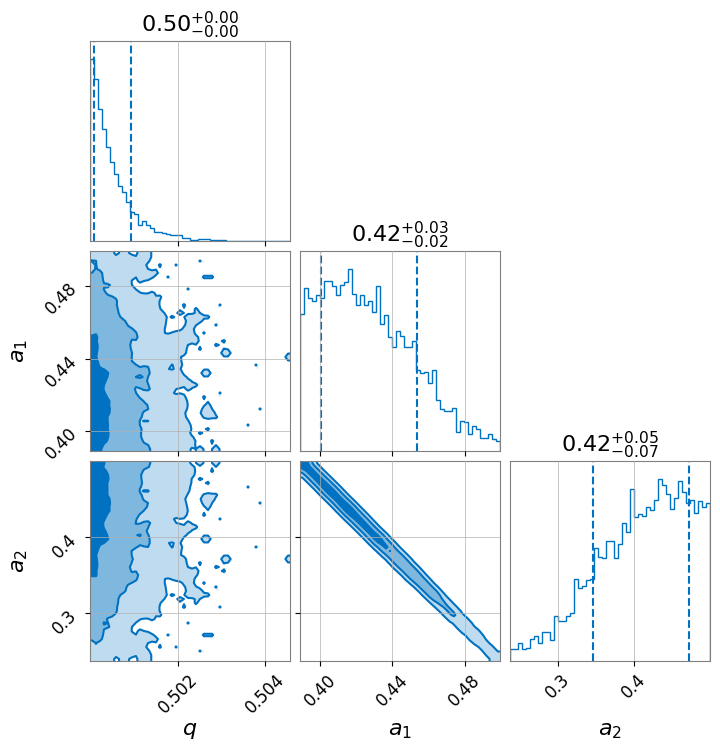

In [ ]:
nlive = 1000          # live points
stop = 0.1            # stopping criterion(change in log of posterior probability)
method = "unif"       # method of sampling
sampler = "dynesty"   # sampler to use

result = bilby.run_sampler(
    likelihood, prior, sampler=sampler, outdir=outdir, label=label,
    conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
    sample=method, nlive=nlive, dlogz=stop)

result.plot_corner()

In [ ]:
posts = result.posterior
#posts = pd.read_csv("/content/drive/My Drive/Results/GW150914_result.json", sep = " ")


NameError: name 'result' is not defined